# Rec Systems I
# Baseline Methods

This workbook is part of a series, listed below:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Rec%20Systems%20I%20-%20Baseline%20Methods.ipynb">Rec Systems I - Baseline Methods</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Rec%20Systems%20II%20-%20Content%20Based.ipynb">Rec Systems II - Content Based</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Rec%20Systems%20III%20-%20User-Based%20Collaborative%20Filtering.ipynb">Rec Systems III - User-Based Collaborative Filtering</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Rec%20Systems%20IV%20-%20Item-Based%20Collaborative%20Filtering.ipynb">Rec Systems IV - Item-Based Collaborative Filtering</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Rec%20Systems%20V%20-%20Matrix%20Factorization.ipynb">Rec Systems V - Matrix Factorization</a>

# Import Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import warnings 
warnings.filterwarnings('ignore')

### Movies Data

In [2]:
movie_info = pd.read_csv('movielens_data/movie_info.csv',header=0,sep=",")
movie_info.head(1)

,movie id,movie title,release date,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-95,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print(np.shape(movie_info))

(1682, 22)


In [4]:
movie_info.isnull().sum()

movie id        0
movie title     0
release date    1
unknown         0
Action          0
Adventure       0
Animation       0
Children's      0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film-Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci-Fi          0
Thriller        0
War             0
Western         0
dtype: int64

### Ratings Data

In [5]:
ratings = pd.read_csv('movielens_data/ratings.csv',header=0,sep=",")
ratings.head(1)

,user_id,movie_id,rating,unix_timestamp
0,196,242,3,881250949


In [6]:
print(np.shape(ratings))

(100000, 4)


In [7]:
ratings

,user_id,movie_id,rating,unix_timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [8]:
ratings.drop(columns='unix_timestamp', inplace=True)

In [9]:
ratings.isnull().sum()

user_id     0
movie_id    0
rating      0
dtype: int64

### User Data

In [10]:
user_info = pd.read_csv('movielens_data/user_demographics.csv',header=0,sep=",")
user_info.head(1)

,user_id,age,sex,occupation,zip_code
0,1,24,M,technician,85711


In [11]:
print(np.shape(user_info))

(943, 5)


In [12]:
user_info.isnull().sum()

user_id       0
age           0
sex           0
occupation    0
zip_code      0
dtype: int64

# Plot Ratings Counts

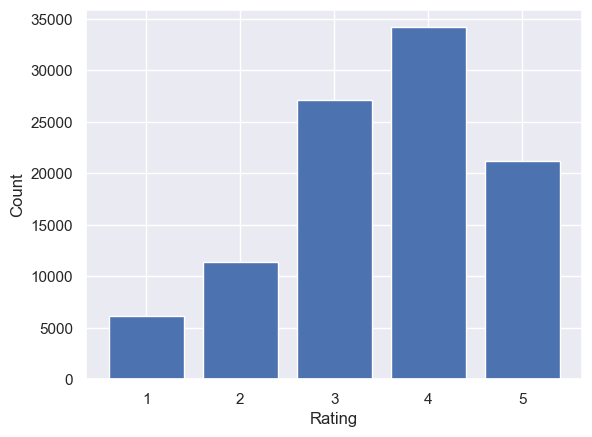

In [13]:
plt.bar(ratings['rating'].value_counts().index, ratings['rating'].value_counts().values)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show();

# Error Metric (RMSE)

In [14]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Baseline Methods

### Train/Test Split

In [15]:
X = ratings.copy()
X_train, X_test = train_test_split(X, test_size = 0.25, random_state=123)

### Simple Average of All Ratings

In [16]:
X_train['rating'].mean()

3.52868

In [17]:
pred = np.repeat(X_train['rating'].mean(),len(X_train))
train_rmse = rmse(X_train['rating'], pred)
train_rmse

1.122712841409889

In [18]:
pred = np.repeat(X_train['rating'].mean(),len(X_test))
test_rmse = rmse(X_test['rating'], pred)
test_rmse

1.134489629040301

In [19]:
results_df = pd.DataFrame(columns=['model', 'train_rmse', 'test_rmse'])

In [20]:
def append_results_df(model, train_rmse, test_rmse):
    new_row = len(results_df) + 1
    results_df.loc[new_row,'model'] = model
    results_df.loc[new_row,'train_rmse'] = round(train_rmse,3)
    results_df.loc[new_row,'test_rmse'] = round(test_rmse,3)

In [21]:
append_results_df('Simple Avg', train_rmse, test_rmse)

### Naive User-Based Average

In [22]:
r_matrix = X_train.pivot_table(values='rating', index='user_id', columns='movie_id')
mean_ratings_df = pd.DataFrame(r_matrix.mean(axis=1), columns=['mean_rating'])
mean_ratings_df.head()

,mean_rating
user_id,
1,3.655172
2,3.711111
3,2.756757
4,4.111111
5,2.939850


In [23]:
user_based_avgs = X_train.merge(mean_ratings_df, how='left', on='user_id')
train_rmse = rmse(user_based_avgs['rating'], user_based_avgs['mean_rating'])

In [24]:
user_based_avgs = X_test.merge(mean_ratings_df, how='left', on='user_id')
test_rmse = rmse(user_based_avgs['rating'], user_based_avgs['mean_rating'])

In [25]:
append_results_df('Naive User-Based', train_rmse, test_rmse)

In [26]:
results_df

,model,train_rmse,test_rmse
1,Simple Avg,1.123,1.134
2,Naive User-Based,1.025,1.054


### Naive Item-Based Average

In [27]:
r_matrix = X_train.pivot_table(values='rating', index='movie_id', columns='user_id')
mean_ratings_df = pd.DataFrame(r_matrix.mean(axis=1), columns=['mean_rating'])

In [28]:
item_based_avgs = X_train.merge(mean_ratings_df, how='left', on='movie_id')
train_rmse = rmse(item_based_avgs['rating'], item_based_avgs['mean_rating'])

In [29]:
item_based_avgs = X_test.merge(mean_ratings_df, how='left', on='movie_id')

In [30]:
null_test_items = item_based_avgs[user_based_avgs['mean_rating'].isnull()]
item_based_avgs = item_based_avgs.dropna(subset=['mean_rating'])
null_test_items['mean_rating'] = X_train['rating'].mean()
concat_df = pd.concat([item_based_avgs, null_test_items])

In [31]:
test_rmse = rmse(concat_df['rating'], concat_df['mean_rating'])

In [32]:
append_results_df('Naive Item-Based', train_rmse, test_rmse)
results_df

,model,train_rmse,test_rmse
1,Simple Avg,1.123,1.134
2,Naive User-Based,1.025,1.054
3,Naive Item-Based,0.995,1.028


### Global Average Weighted by Vote Count

In [33]:
count_matrix = X_train.pivot_table(values='rating', index='user_id', columns='movie_id', aggfunc='count')

In [34]:
df = X_train.drop(columns='user_id').copy()
counts = df.groupby(['movie_id']).count()
ratings_df = df.groupby(['movie_id']).sum() / df.groupby(['movie_id']).count()
ratings_df = ratings_df.merge(counts, how='left', on='movie_id')
ratings_df = ratings_df.rename(columns={'rating_x':'avg', 'rating_y':'count'})

In [35]:
ratings_df['product'] = ratings_df['avg'] * ratings_df['count']
weighted_avg = ratings_df['product'].sum() / ratings_df['count'].sum()
weighted_avg

3.52868

In [36]:
pred = np.repeat(weighted_avg,len(X_train))
train_rmse = rmse(X_train['rating'], pred)

In [37]:
pred = np.repeat(weighted_avg,len(X_test))
test_rmse = rmse(X_test['rating'], pred)

In [38]:
append_results_df('Vote-Weighted Avg', train_rmse, test_rmse)
results_df

,model,train_rmse,test_rmse
1,Simple Avg,1.123,1.134
2,Naive User-Based,1.025,1.054
3,Naive Item-Based,0.995,1.028
4,Vote-Weighted Avg,1.123,1.134


# IMDB's Weighted Rating Formula

IMDB has been known to use a weighting formula of:
    
<h1>$Weighted Rating = \left( \frac{v}{v+m} \right) \times R + \left( \frac{m}{v+m} \right) \times C$</h1>

- $v$ is the number of votes garnered by the movie
- $m$ is the minimum number of votes required for the movie to be in the chart
- $R$ is the mean rating of the movie
- $C$ is the mean rating of all the movies in the dataset

<i>Source: Analytics Vidhya</i>

In [39]:
v = X_train.groupby(['movie_id']).count().drop(columns='user_id')
v = v.rename(columns={'rating': 'count'})
m = 50
R = X_train.drop(columns='user_id')
R = R.groupby(['movie_id']).sum() / R.groupby(['movie_id']).count()
R = R.rename(columns={'rating': 'avg_rating'})
C = X_train['rating'].mean()

In [40]:
df = pd.DataFrame()
df['movie_id'] = X_train['movie_id'].value_counts().index
df = df.merge(v, how='left', on='movie_id')
df = df.merge(R, how='left', on='movie_id')

In [41]:
df.head(1)

,movie_id,count,avg_rating
0,50,426,4.314554


In [42]:
df['wranking'] = np.NaN

for i in tqdm(range(len(df))):
    v = df['count'][i]
    R = df['avg_rating'][i]
    # C and m are scalars defined above
    wranking = ( v/(v+m) ) * R + ( m/(v+m) ) * C
    df['wranking'][i] = wranking    

100%|██████████| 1641/1641 [00:00<00:00, 4144.43it/s]


In [43]:
df.head(1)

,movie_id,count,avg_rating,wranking
0,50,426,4.314554,4.232004


In [44]:
X_train.head(1)

,user_id,movie_id,rating
31450,496,136,1


In [45]:
X_train = X_train.merge(df, how='left', on='movie_id')
X_train.head(1)

,user_id,movie_id,rating,count,avg_rating,wranking
0,496,136,1,78,4.141026,3.901828


In [51]:
train_rmse = rmse(X_train['rating'], X_train['wranking'])

In [47]:
X_test = X_test.merge(df, how='left', on='movie_id')
X_test['wranking'].isnull().sum()

45

In [48]:
X_test['wranking'] = X_test['wranking'].fillna(C)
X_test['wranking'].isnull().sum()

0

In [50]:
test_rmse = rmse(X_test['rating'], X_test['wranking'])

In [52]:
append_results_df('IMDB Weighted Avg', train_rmse, test_rmse)
results_df

,model,train_rmse,test_rmse
1,Simple Avg,1.123,1.134
2,Naive User-Based,1.025,1.054
3,Naive Item-Based,0.995,1.028
4,Vote-Weighted Avg,1.123,1.134
5,IMDB Weighted Avg,1.036,1.052


The next workbook in the series looks at content (e.g. description) based methods, and can be found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Rec%20Systems%20II%20-%20Content%20Based.ipynb">here</a>.